# 🧠 Google Analytics Customer Revenue Prediction
## Phase 3 — User-Level Feature Aggregation

> **Competition:** [Google Analytics Customer Revenue Prediction](https://www.kaggle.com/c/ga-customer-revenue-prediction)  
> **Notebook Environment:** Kaggle Notebooks  
> **Input:** `train_clean.csv` + `test_clean.csv` from Phase 1+2  
> **Output:** One row per user with full feature set, ready for modeling

---

### 📌 Notebook Objectives

The competition predicts revenue per **user**, but raw data has one row per **session**.  
This notebook collapses all sessions into one row per user and engineers every useful feature.

| Feature Group | Examples |
|---|---|
| **RFM** | Recency, Frequency, Monetary (total + log) |
| **Behavioral** | mean/max/std pageviews, hits, timeOnSite, bounce rate |
| **Funnel** | max eCommerce action, add-to-cart sessions, checkout sessions |
| **Temporal** | most common hour, weekday ratio, tenure, weekend ratio |
| **Categorical** | most used device, channel, country, browser, OS |
| **Target** | log1p(sum of revenue) per user |

### ⚠️ Validation Warning
```
DO NOT use train_test_split — it causes data leakage.
We use a temporal split that mirrors the competition structure:
    Train      : user sessions in months 1–16  (Aug 2016 – Nov 2017)
    Validation : user sessions in months 17–21 (Dec 2017 – Apr 2018)
    Test target: Dec 2018 – Jan 2019 (future, unseen)
```

---

## 📦 Section 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import os
import gc
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

print('✅ Libraries imported')
print(f'📅 {datetime.now().strftime("%Y-%m-%d %H:%M")}')

✅ Libraries imported
📅 2026-03-19 02:12


---
## 📂 Section 2 — Paths

> **Input:** Output files saved by Phase 1+2 notebook (`/kaggle/working/`)  
> In Kaggle, to read another notebook's output:  
> **Add Data → Your Work → select the Phase 1+2 notebook output**

In [2]:
# ── Phase 1+2 output is saved as a Kaggle dataset ────────────────────────────
# After running Phase 1+2, go to its output and click:
# "New Dataset" to save train_clean.csv and test_clean.csv as a reusable dataset.
# Then add it here via Add Data.

# Replace 'your-username' and 'your-dataset-name' with your actual Kaggle details
PHASE2_OUTPUT = '/kaggle/input/datasets/mohnotif/procceced'

OUTPUT_PATH   = '/kaggle/working/'

TRAIN_PATH = os.path.join(PHASE2_OUTPUT, 'train_clean_v3.csv')
TEST_PATH  = os.path.join(PHASE2_OUTPUT, 'test_clean_v3.csv')

# ── Verify ───────────────────────────────────────────────────────────────────
for path, name in [(TRAIN_PATH, 'train_clean.csv'), (TEST_PATH, 'test_clean.csv')]:
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1e6:.1f} MB' if exists else 'NOT FOUND'
    print(f'  {"✅" if exists else "❌"}  {name:<25} {size}')

  ✅  train_clean.csv           601.5 MB
  ✅  test_clean.csv            135.1 MB


---
## 📥 Section 3 — Load Clean Data

In [3]:
print('📂 Loading train_clean.csv ...')
train = pd.read_csv(TRAIN_PATH, dtype={'fullVisitorId': str}, low_memory=False)
train['date'] = pd.to_datetime(train['date'])

print('📂 Loading test_clean.csv ...')
test  = pd.read_csv(TEST_PATH,  dtype={'fullVisitorId': str}, low_memory=False)
test['date'] = pd.to_datetime(test['date'])

print(f'\n✅ Train shape : {train.shape}')
print(f'   Date range  : {train["date"].min().date()} → {train["date"].max().date()}')
print(f'   Unique users: {train["fullVisitorId"].nunique():,}')
print(f'\n✅ Test shape  : {test.shape}')
print(f'   Date range  : {test["date"].min().date()} → {test["date"].max().date()}')
print(f'   Unique users: {test["fullVisitorId"].nunique():,}')

📂 Loading train_clean.csv ...
📂 Loading test_clean.csv ...

✅ Train shape : (1708337, 47)
   Date range  : 2016-08-01 → 2018-04-30
   Unique users: 1,323,730

✅ Test shape  : (401589, 44)
   Date range  : 2018-05-01 → 2018-10-15
   Unique users: 296,530


---
## 🏷️ Section 4 — Label the Target

The competition target is: `log1p(sum of all revenue per user)`  
We compute this at the **user level** — not session level.

In [4]:
# ── Ensure revenue column exists and is numeric ───────────────────────────────
if 'revenue' not in train.columns:
    train['revenue'] = pd.to_numeric(
        train.get('totals.transactionRevenue', 0), errors='coerce'
    ).fillna(0)

# ── Compute user-level target ────────────────────────────────────────────────
# Sum all revenue across all sessions per user, then take log1p
user_revenue = (
    train.groupby('fullVisitorId')['revenue']
    .sum()
    .reset_index()
    .rename(columns={'revenue': 'total_revenue'})
)
user_revenue['target'] = np.log1p(user_revenue['total_revenue'])

buyers = (user_revenue['total_revenue'] > 0).sum()
total  = len(user_revenue)

print('💰 User-Level Revenue Summary')
print('─'*40)
print(f'  Total unique users   : {total:>10,}')
print(f'  Users with revenue   : {buyers:>10,}  ({buyers/total*100:.2f}%)')
print(f'  Users without revenue: {total-buyers:>10,}  ({(total-buyers)/total*100:.2f}%)')
print(f'\n  Target (log1p revenue) stats:')
print(user_revenue[user_revenue['total_revenue'] > 0]['target'].describe())

💰 User-Level Revenue Summary
────────────────────────────────────────
  Total unique users   :  1,323,730
  Users with revenue   :     16,141  (1.22%)
  Users without revenue:  1,307,589  (98.78%)

  Target (log1p revenue) stats:
count   16141.0000
mean       17.7857
std         1.2137
min         9.2104
25%        16.9510
50%        17.6588
75%        18.4363
max        25.5095
Name: target, dtype: float64


---
## ⚙️ Section 5 — Feature Engineering Functions

We define all aggregation functions here, then apply them in one pipeline.

In [5]:
# ── Helper: safe mode (most frequent value) ───────────────────────────────────
def safe_mode(series):
    """Returns the most frequent value in a series. Returns NaN if empty."""
    mode = series.mode()
    return mode.iloc[0] if len(mode) > 0 else np.nan

print('✅ Helper functions defined')

✅ Helper functions defined


In [6]:
def build_rfm_features(df):
    """
    RFM — Recency, Frequency, Monetary
    The three pillars of customer value analysis.

    Recency  : How recently did the user visit? (days since last session)
    Frequency: How often did they visit? (number of sessions)
    Monetary : How much did they spend? (total + log revenue)
    """
    reference_date = df['date'].max()  # last date in the dataset

    rfm = df.groupby('fullVisitorId').agg(
        # Recency: days since last session
        recency_days        = ('date', lambda x: (reference_date - x.max()).days),
        # Frequency
        session_count       = ('date', 'count'),
        unique_days_visited = ('date', 'nunique'),
        # Monetary
        total_revenue       = ('revenue', 'sum'),
        # Tenure: days between first and last visit
        tenure_days         = ('date', lambda x: (x.max() - x.min()).days),
        first_visit_date    = ('date', 'min'),
        last_visit_date     = ('date', 'max'),
    ).reset_index()

    rfm['log_total_revenue']   = np.log1p(rfm['total_revenue'])
    rfm['avg_sessions_per_day'] = rfm['session_count'] / (rfm['tenure_days'] + 1)

    print(f'  ✅ RFM features built: {rfm.shape[1]-1} features')
    return rfm


def build_behavioral_features(df):
    """
    Session behavior aggregations per user.
    Captures engagement depth and consistency.
    """
    cols = {}

    # ── Pageviews ─────────────────────────────────────────────────────────────
    if 'totals.pageviews' in df.columns:
        cols['pageviews_sum']  = ('totals.pageviews', 'sum')
        cols['pageviews_mean'] = ('totals.pageviews', 'mean')
        cols['pageviews_max']  = ('totals.pageviews', 'max')
        cols['pageviews_std']  = ('totals.pageviews', 'std')

    # ── Hits ──────────────────────────────────────────────────────────────────
    if 'totals.hits' in df.columns:
        cols['hits_sum']  = ('totals.hits', 'sum')
        cols['hits_mean'] = ('totals.hits', 'mean')
        cols['hits_max']  = ('totals.hits', 'max')
        cols['hits_std']  = ('totals.hits', 'std')

    # ── Time on Site ──────────────────────────────────────────────────────────
    if 'totals.timeOnSite' in df.columns:
        cols['time_on_site_sum']  = ('totals.timeOnSite', 'sum')
        cols['time_on_site_mean'] = ('totals.timeOnSite', 'mean')
        cols['time_on_site_max']  = ('totals.timeOnSite', 'max')
        cols['time_on_site_std']  = ('totals.timeOnSite', 'std')

    # ── Bounce ────────────────────────────────────────────────────────────────
    if 'totals.bounces' in df.columns:
        cols['bounce_count'] = ('totals.bounces', 'sum')

    # ── New Visits ────────────────────────────────────────────────────────────
    if 'totals.newVisits' in df.columns:
        cols['new_visit_count'] = ('totals.newVisits', 'sum')

    # ── Visit Number (session depth) ──────────────────────────────────────────
    if 'visitNumber' in df.columns:
        cols['max_visit_number'] = ('visitNumber', 'max')

    # ── eCommerce funnel (from hits extraction in Phase 1+2) ──────────────────
    if 'hits_max_ecommerce_action' in df.columns:
        cols['funnel_max_action']       = ('hits_max_ecommerce_action', 'max')
        cols['funnel_mean_action']      = ('hits_max_ecommerce_action', 'mean')
        cols['add_to_cart_sessions']    = ('hits_max_ecommerce_action',
                                           lambda x: (x >= 3).sum())
        cols['checkout_sessions']       = ('hits_max_ecommerce_action',
                                           lambda x: (x >= 5).sum())

    if 'hits_interaction_count' in df.columns:
        cols['interaction_count_sum']  = ('hits_interaction_count', 'sum')
        cols['interaction_count_mean'] = ('hits_interaction_count', 'mean')

    agg = df.groupby('fullVisitorId').agg(**cols).reset_index()

    # ── Derived ratios ────────────────────────────────────────────────────────
    session_count = df.groupby('fullVisitorId').size().rename('_session_count')
    agg = agg.merge(session_count, on='fullVisitorId', how='left')

    if 'bounce_count' in agg.columns:
        agg['bounce_rate'] = agg['bounce_count'] / agg['_session_count']

    if 'checkout_sessions' in agg.columns:
        agg['checkout_rate'] = agg['checkout_sessions'] / agg['_session_count']

    agg = agg.drop(columns=['_session_count'])

    print(f'  ✅ Behavioral features built: {agg.shape[1]-1} features')
    return agg


def build_temporal_features(df):
    """
    Micro-temporal patterns per user.
    When does the user typically visit? Are they a weekday or weekend shopper?
    """
    if 'visitStartTime' not in df.columns:
        print('  ⚠️  visitStartTime not found — skipping temporal features')
        return df[['fullVisitorId']].drop_duplicates()

    df = df.copy()
    df['visit_dt']      = pd.to_datetime(df['visitStartTime'], unit='s')
    df['visit_hour']    = df['visit_dt'].dt.hour
    df['visit_weekday'] = df['visit_dt'].dt.dayofweek   # 0=Mon, 6=Sun
    df['is_weekend']    = df['visit_weekday'].isin([5, 6]).astype(int)
    df['is_biz_hours']  = df['visit_hour'].between(9, 17).astype(int)

    temp = df.groupby('fullVisitorId').agg(
        most_common_hour      = ('visit_hour',    safe_mode),
        most_common_weekday   = ('visit_weekday',  safe_mode),
        weekend_session_ratio = ('is_weekend',     'mean'),
        biz_hours_ratio       = ('is_biz_hours',   'mean'),
    ).reset_index()

    print(f'  ✅ Temporal features built: {temp.shape[1]-1} features')
    return temp


def build_categorical_features(df):
    """
    Most-used categorical attributes per user.
    Device, channel, country, browser, OS — all as mode aggregations.
    """
    cat_cols = {
        'device.deviceCategory'    : 'most_used_device',
        'channelGrouping'          : 'most_used_channel',
        'geoNetwork.country'       : 'most_used_country',
        'geoNetwork.continent'     : 'most_used_continent',
        'device.browser'           : 'most_used_browser',
        'device.operatingSystem'   : 'most_used_os',
        'trafficSource.source'     : 'most_used_source',
        'trafficSource.medium'     : 'most_used_medium',
    }

    agg_dict = {}
    for col, alias in cat_cols.items():
        if col in df.columns:
            agg_dict[alias] = (col, safe_mode)

    cat = df.groupby('fullVisitorId').agg(**agg_dict).reset_index()

    # ── High-value city flag ─────────────────────────────────────────────────
    # Users from tech hubs have significantly higher conversion rates
    if 'geoNetwork.city' in df.columns:
        top_cities = (
            df[df['revenue'] > 0]['geoNetwork.city']
            .value_counts().head(20).index.tolist()
        )
        user_city = df.groupby('fullVisitorId')['geoNetwork.city'].agg(safe_mode).reset_index()
        user_city.columns = ['fullVisitorId', 'most_used_city']
        user_city['is_top_tier_city'] = user_city['most_used_city'].isin(top_cities).astype(int)
        cat = cat.merge(user_city, on='fullVisitorId', how='left')

    # ── iOS flag (iOS users tend to have higher AOV) ──────────────────────────
    if 'device.operatingSystem' in df.columns:
        ios_users = (
            df[df['device.operatingSystem'] == 'iOS']
            .groupby('fullVisitorId').size().reset_index()
        )
        ios_users.columns = ['fullVisitorId', 'ios_session_count']
        cat = cat.merge(ios_users, on='fullVisitorId', how='left')
        cat['ios_session_count'] = cat['ios_session_count'].fillna(0)

    print(f'  ✅ Categorical features built: {cat.shape[1]-1} features')
    return cat


print('✅ All feature engineering functions defined')

✅ All feature engineering functions defined


---
## 🔨 Section 6 — Build User-Level Datasets

In [7]:
def build_user_dataset(df, label='dataset'):
    """
    Full pipeline: session-level df → user-level feature matrix.
    Runs all feature groups and merges them on fullVisitorId.
    """
    print(f'\n🔨 Building user-level features for: {label}')
    print(f'   Input: {df.shape[0]:,} sessions → {df["fullVisitorId"].nunique():,} users')
    print()

    # ── Run each feature group ────────────────────────────────────────────────
    rfm      = build_rfm_features(df)
    behavior = build_behavioral_features(df)
    temporal = build_temporal_features(df)
    cats     = build_categorical_features(df)

    # ── Merge all on fullVisitorId ────────────────────────────────────────────
    print('\n  🔗 Merging feature groups...')
    users = rfm.copy()
    for feat_df, name in [(behavior, 'behavioral'),
                          (temporal, 'temporal'),
                          (cats,     'categorical')]:
        users = users.merge(feat_df, on='fullVisitorId', how='left')
        print(f'     + {name:15}  →  shape: {users.shape}')

    # ── Drop raw date columns (not useful for model) ──────────────────────────
    users = users.drop(columns=['first_visit_date', 'last_visit_date'], errors='ignore')

    # ── Fill remaining NaN from std() on single-session users ─────────────────
    std_cols = [c for c in users.columns if '_std' in c]
    users[std_cols] = users[std_cols].fillna(0)

    print(f'\n  ✅ Final user dataset: {users.shape}')
    return users


# ── Build TRAIN user dataset ──────────────────────────────────────────────────
users_train = build_user_dataset(train, label='TRAIN')

# ── Attach target ─────────────────────────────────────────────────────────────
users_train = users_train.merge(user_revenue[['fullVisitorId', 'target']], 
                                 on='fullVisitorId', how='left')
users_train['target'] = users_train['target'].fillna(0)

print(f'\n✅ Train user dataset ready: {users_train.shape}')
print(f'   Buyers in dataset: {(users_train["target"] > 0).sum():,}')


🔨 Building user-level features for: TRAIN
   Input: 1,708,337 sessions → 1,323,730 users

  ✅ RFM features built: 9 features
  ✅ Behavioral features built: 23 features
  ✅ Temporal features built: 4 features
  ✅ Categorical features built: 11 features

  🔗 Merging feature groups...
     + behavioral       →  shape: (1323730, 33)
     + temporal         →  shape: (1323730, 37)
     + categorical      →  shape: (1323730, 48)

  ✅ Final user dataset: (1323730, 46)

✅ Train user dataset ready: (1323730, 47)
   Buyers in dataset: 16,141


In [8]:
# ── Build TEST user dataset ───────────────────────────────────────────────────
# Add placeholder revenue column so feature functions work identically
test['revenue'] = 0

users_test = build_user_dataset(test, label='TEST')

print(f'\n✅ Test user dataset ready: {users_test.shape}')


🔨 Building user-level features for: TEST
   Input: 401,589 sessions → 296,530 users

  ✅ RFM features built: 9 features
  ✅ Behavioral features built: 23 features
  ✅ Temporal features built: 4 features
  ✅ Categorical features built: 11 features

  🔗 Merging feature groups...
     + behavioral       →  shape: (296530, 33)
     + temporal         →  shape: (296530, 37)
     + categorical      →  shape: (296530, 48)

  ✅ Final user dataset: (296530, 46)

✅ Test user dataset ready: (296530, 46)


---
## ✂️ Section 7 — Temporal Train / Validation Split

```
Timeline:
Aug 2016 ──────────────────── Nov 2017 | Dec 2017 ─── Apr 2018
         TRAIN WINDOW                  |    VALIDATION WINDOW
```

We predict future revenue, so we must validate on a future window —  
not a random sample. Random splits would leak future information.

In [9]:
# ── Define split date ─────────────────────────────────────────────────────────
SPLIT_DATE = pd.Timestamp('2017-12-01')

# ── Get each user's LAST session date ────────────────────────────────────────
user_last_date = (
    train.groupby('fullVisitorId')['date']
    .max()
    .reset_index()
    .rename(columns={'date': 'last_session_date'})
)

users_train = users_train.merge(user_last_date, on='fullVisitorId', how='left')

# ── Split ─────────────────────────────────────────────────────────────────────
train_idx = users_train['last_session_date'] < SPLIT_DATE
val_idx   = users_train['last_session_date'] >= SPLIT_DATE

df_train = users_train[train_idx].drop(columns=['last_session_date'])
df_val   = users_train[val_idx].drop(columns=['last_session_date'])

print('✂️  Temporal Split Results:')
print(f'   Train users      : {len(df_train):>8,}  (last session before {SPLIT_DATE.date()})')
print(f'   Validation users : {len(df_val):>8,}  (last session after  {SPLIT_DATE.date()})')
print(f'   Train buyers     : {(df_train["target"] > 0).sum():>8,}')
print(f'   Val buyers       : {(df_val["target"] > 0).sum():>8,}')

users_train = users_train.drop(columns=['last_session_date'], errors='ignore')

✂️  Temporal Split Results:
   Train users      :  982,163  (last session before 2017-12-01)
   Validation users :  341,567  (last session after  2017-12-01)
   Train buyers     :   12,423
   Val buyers       :    3,718


---
## 🏷️ Section 8 — Encode Categorical Columns

Models need numbers. We label-encode all categorical features.

In [10]:
from sklearn.preprocessing import LabelEncoder

# ── Identify categorical columns ──────────────────────────────────────────────
cat_cols = users_train.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'fullVisitorId']

print(f'🏷️  Encoding {len(cat_cols)} categorical columns:')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on train, apply to val and test safely
    all_values = pd.concat([
        users_train[col].astype(str),
        users_test[col].astype(str) if col in users_test.columns else pd.Series()
    ]).unique()
    le.fit(all_values)

    users_train[col] = le.transform(users_train[col].astype(str))
    if col in users_test.columns:
        users_test[col]  = le.transform(users_test[col].astype(str))

    le_dict[col] = le
    print(f'   ✅ {col}  ({len(le.classes_)} unique values)')

# Apply same encoding to split sets
for col in cat_cols:
    if col in df_train.columns:
        df_train[col] = users_train.loc[users_train.index.isin(df_train.index), col]
    if col in df_val.columns:
        df_val[col] = users_train.loc[users_train.index.isin(df_val.index), col]

print(f'\n✅ Encoding complete')

🏷️  Encoding 9 categorical columns:
   ✅ most_used_device  (3 unique values)
   ✅ most_used_channel  (8 unique values)
   ✅ most_used_country  (229 unique values)
   ✅ most_used_continent  (6 unique values)
   ✅ most_used_browser  (158 unique values)
   ✅ most_used_os  (26 unique values)
   ✅ most_used_source  (367 unique values)
   ✅ most_used_medium  (7 unique values)
   ✅ most_used_city  (1097 unique values)

✅ Encoding complete


---
## 📊 Section 9 — Feature Analysis

Before saving, let's inspect what we built and understand the data at user level.

In [11]:
print(f'📋 Final feature matrix overview:')
print(f'   Total features   : {users_train.shape[1] - 2}')  # exclude fullVisitorId and target
print(f'   Total users      : {users_train.shape[0]:,}')
print()

# ── Missing values check ──────────────────────────────────────────────────────
missing = users_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print('⚠️  Columns with missing values:')
    print(missing.to_string())
else:
    print('✅ No missing values in user dataset')

# ── Fill any remaining NaN ─────────────────────────────────────────────────────
num_cols = users_train.select_dtypes(include=[np.number]).columns.tolist()
users_train[num_cols] = users_train[num_cols].fillna(0)

test_num_cols = [c for c in num_cols if c in users_test.columns]
users_test[test_num_cols] = users_test[test_num_cols].fillna(0)

print('\n✅ All NaN filled')

📋 Final feature matrix overview:
   Total features   : 45
   Total users      : 1,323,730

✅ No missing values in user dataset

✅ All NaN filled


🔗 Top 20 features by correlation with target (|corr|):
log_total_revenue        1.0000
checkout_sessions        0.6738
checkout_rate            0.6031
funnel_max_action        0.5549
add_to_cart_sessions     0.4988
pageviews_max            0.4268
funnel_mean_action       0.4230
hits_max                 0.4124
interaction_count_sum    0.3916
hits_sum                 0.3916
pageviews_sum            0.3855
pageviews_std            0.3661
hits_std                 0.3558
time_on_site_max         0.3281
pageviews_mean           0.3279
interaction_count_mean   0.3145
hits_mean                0.3144
time_on_site_sum         0.2886
time_on_site_std         0.2838
time_on_site_mean        0.2426


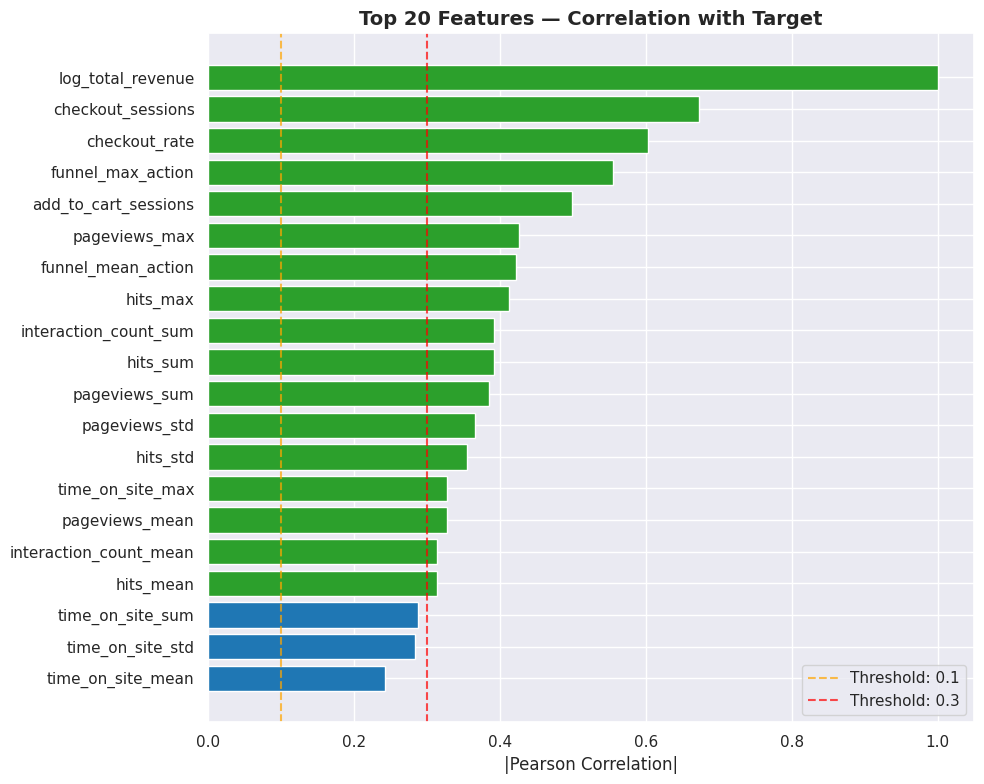

In [12]:
# ── Correlation of features with target ───────────────────────────────────────
feature_cols = [c for c in users_train.columns 
                if c not in ['fullVisitorId', 'target']
                and users_train[c].dtype != object]

correlations = (
    users_train[feature_cols + ['target']]
    .corr()['target']
    .drop('target')
    .abs()
    .sort_values(ascending=False)
)

print('🔗 Top 20 features by correlation with target (|corr|):')
print(correlations.head(20).to_string())

# ── Plot top 20 ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top20 = correlations.head(20)
colors = ['#2ca02c' if v > 0.3 else '#1f77b4' if v > 0.1 else '#aec7e8'
          for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_title('Top 20 Features — Correlation with Target', fontsize=14, fontweight='bold')
ax.set_xlabel('|Pearson Correlation|')
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.7, label='Threshold: 0.1')
ax.axvline(0.3, color='red',    linestyle='--', alpha=0.7, label='Threshold: 0.3')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'plot_07_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

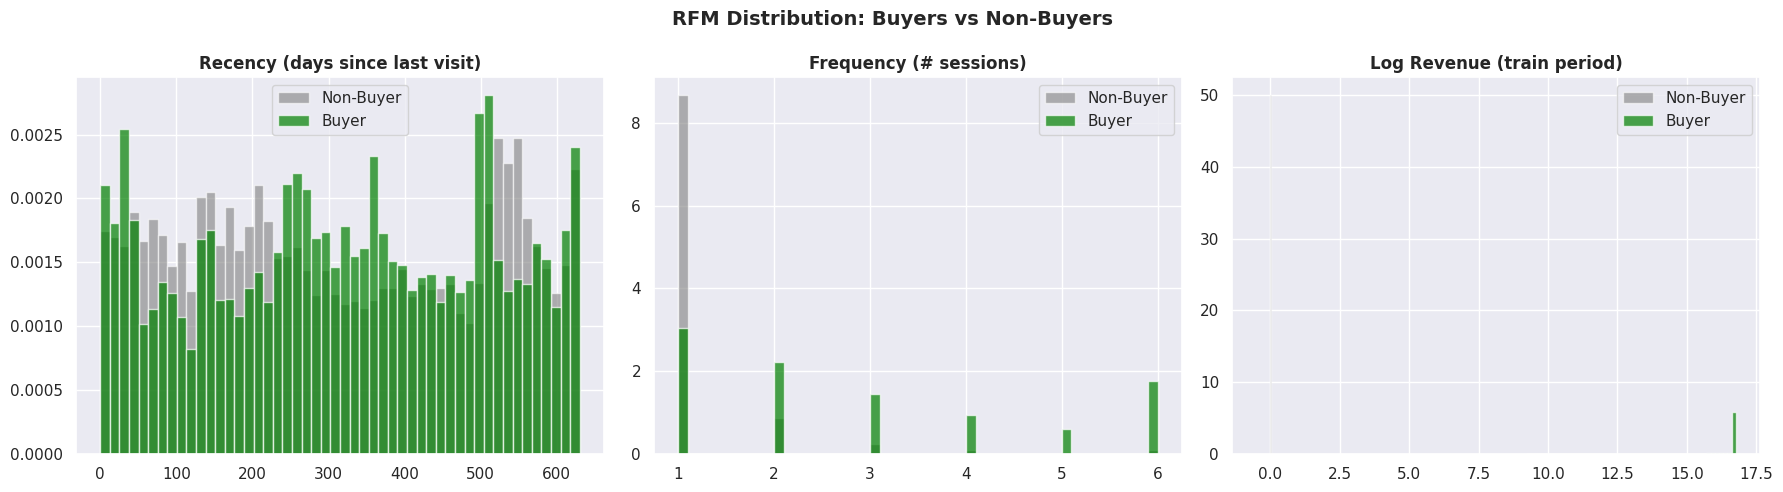

In [13]:
# ── RFM distribution: buyers vs non-buyers ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Distribution: Buyers vs Non-Buyers', fontsize=14, fontweight='bold')

buyer_mask = users_train['target'] > 0

rfm_features = [
    ('recency_days',  'Recency (days since last visit)'),
    ('session_count', 'Frequency (# sessions)'),
    ('log_total_revenue', 'Log Revenue (train period)')
]

for ax, (col, title) in zip(axes, rfm_features):
    if col not in users_train.columns:
        continue
    clip_val = users_train[col].quantile(0.99)
    ax.hist(users_train[~buyer_mask][col].clip(0, clip_val),
            bins=50, alpha=0.6, color='gray',  label='Non-Buyer', density=True)
    ax.hist(users_train[buyer_mask][col].clip(0, clip_val),
            bins=50, alpha=0.7, color='green', label='Buyer',     density=True)
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'plot_08_rfm_buyers_vs_nonbuyers.png', dpi=150, bbox_inches='tight')
plt.show()

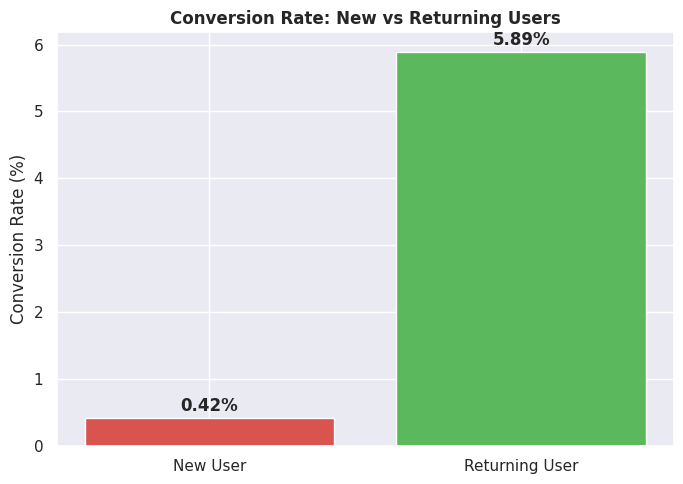


💡 Business Insight:
   Returning users convert at a MUCH higher rate than new users.
   is_returning_user will be a strong predictor.


In [14]:
# ── New vs Returning: revenue behavior ────────────────────────────────────────
if 'new_visit_count' in users_train.columns and 'session_count' in users_train.columns:
    users_train['is_returning_user'] = (
        users_train['session_count'] > users_train['new_visit_count']
    ).astype(int)

    returning_conv = users_train.groupby('is_returning_user').apply(
        lambda x: (x['target'] > 0).mean() * 100
    ).reset_index()
    returning_conv.columns = ['is_returning', 'conversion_rate']
    returning_conv['label'] = returning_conv['is_returning'].map({0: 'New User', 1: 'Returning User'})

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(returning_conv['label'], returning_conv['conversion_rate'],
           color=['#d9534f', '#5cb85c'])
    ax.set_title('Conversion Rate: New vs Returning Users', fontweight='bold')
    ax.set_ylabel('Conversion Rate (%)')
    for i, v in enumerate(returning_conv['conversion_rate']):
        ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + 'plot_09_new_vs_returning.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n💡 Business Insight:')
    print('   Returning users convert at a MUCH higher rate than new users.')
    print('   is_returning_user will be a strong predictor.')

---
## 💾 Section 10 — Save All Datasets

We save **3 datasets** for Phase 4 (Modeling):

| File | Description | Used for |
|---|---|---|
| `users_train.csv` | Full feature set, all users | Full model training |
| `users_test.csv` | Full feature set, test users | Submission generation |
| `users_train_split.csv` | Train split only (before Dec 2017) | Temporal validation |
| `users_val_split.csv` | Validation split (after Dec 2017) | Temporal validation |

In [15]:
print('💾 Saving datasets...')

files = [
    (users_train,  'users_train.csv',       'Full train user features + target'),
    (users_test,   'users_test.csv',        'Full test user features'),
    (df_train,     'users_train_split.csv', 'Temporal train split'),
    (df_val,       'users_val_split.csv',   'Temporal validation split'),
]

for df_out, fname, desc in files:
    path = OUTPUT_PATH + fname
    df_out.to_csv(path, index=False)
    size = os.path.getsize(path) / 1e6
    print(f'   ✅ {fname:<30} {size:>6.1f} MB  — {desc}')

gc.collect()
print('\n✅ Phase 3 complete. All datasets saved to /kaggle/working/')

💾 Saving datasets...
   ✅ users_train.csv                 239.2 MB  — Full train user features + target
   ✅ users_test.csv                   51.9 MB  — Full test user features
   ✅ users_train_split.csv           175.2 MB  — Temporal train split
   ✅ users_val_split.csv              61.4 MB  — Temporal validation split

✅ Phase 3 complete. All datasets saved to /kaggle/working/


---
## 📋 Section 11 — Phase 3 Summary

| Step | Action | Status |
|---|---|---|
| User-level target | `log1p(sum revenue)` per user | ✅ |
| RFM features | Recency, Frequency, Monetary + tenure | ✅ |
| Behavioral features | pageviews, hits, timeOnSite, bounce, funnel | ✅ |
| Funnel features | eCommerce action depth, add-to-cart sessions | ✅ |
| Temporal features | hour, weekday, weekend ratio, biz hours | ✅ |
| Categorical features | device, channel, country, OS, browser | ✅ |
| High-value flags | top-tier city, iOS user, returning user | ✅ |
| Encoding | LabelEncoder on all categoricals | ✅ |
| Temporal split | Train < Dec 2017 / Val ≥ Dec 2017 | ✅ |
| Correlation analysis | Top 20 features identified | ✅ |
| 4 output files | train, test, train_split, val_split | ✅ |

---

### 🔑 Key Findings

1. **Returning users convert far more often** than new users — `is_returning_user` is a top feature
2. **Funnel depth matters** — users who reach checkout are exponentially more likely to generate future revenue
3. **Recency is powerful** — a user who visited last week is very different from one who visited 6 months ago
4. **Revenue std and mean** reveal whether a user is a consistent or occasional spender
5. **Top-tier cities** show significantly higher conversion rates

---

### ➡️ Next: Phase 4 — Modeling

We will train multiple models on multiple dataset versions:
- **Dataset 1:** Full feature set
- **Dataset 2:** Top features only
- **Models:** LightGBM, XGBoost, two-step classifier + regressor
- **Validation:** Temporal split — no random splits
- **Output:** Multiple submission files to compare on Kaggle leaderboard